# Demande conditionnelle des facteurs avec contrôles en 2022

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

## Préparation de la base de données

### Chargement des données 

In [2]:
finess = pd.read_csv("t-finess.csv", sep=",", encoding="utf-8")
sygen = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
urg = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
filtre = pd.read_csv("SAE/2022/FILTRE_2022r.csv", sep=";", decimal = ",", encoding="latin-1")
hd = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")
chu = pd.read_excel("CHRU.xlsx")

/tmp/ipykernel_37468/785362906.py:1: DtypeWarning: Columns (2,3,8,10,17,26) have mixed types. Specify dtype option on import or set low_memory=False.
  finess = pd.read_csv("t-finess.csv", sep=",", encoding="utf-8")


### Fusion des bases

In [3]:
data = sygen[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_DIR','EFF_AUTADM','EFF_INFSANSSPE','SEAN_HEMO_CENTRE','SEAN_CHIMIO',
              'SEAN_RADIO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEJHC_SSR','ENT','EFF_AID','SEJHP_MCO','SEJHC_MCO', "JOU_MCO"]]
data['FI'] = data['FI'].astype(object)

/tmp/ipykernel_37468/2345331275.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['FI'] = data['FI'].astype(object)


In [4]:
finess = finess.rename(columns={"finess":"FI","statut_jur_niv2_lib":"Statut"})
finess = finess[["FI","Statut"]]
finess = finess.rename(columns={'finess':'FI', "statut_jur_niv2_lib":'Statut'})
finess['FI'] = finess['FI'].astype(object)

# Si la longueur est 8, on ajoute '0' au début, sinon on garde la valeur telle quelle
finess['FI'] = finess['FI'].apply(lambda x: '0' + str(x) if len(str(x)) == 8 else str(x))

chu["FINESS"] = chu["FINESS"].astype(object)
chu = chu.rename(columns={"FINESS":"FI"})
chu['FI'] = chu['FI'].apply(lambda x: '0' + str(x) if len(str(x)) == 8 else str(x))
finess.loc[finess['FI'].isin(chu['FI']), "Statut"] = "CHU"  #Ajout du statut CHU dans la colonne Statut de FINESS

data = data.merge(finess, on="FI", how="left")

In [5]:
data[data['Statut'].isna()]
#problème de 115 établissements sans statut résolu

,FI,FI_EJ,EFFSAL_TOT,EFFLIB_TOT,EFF_DIR,EFF_AUTADM,EFF_INFSANSSPE,SEAN_HEMO_CENTRE,SEAN_CHIMIO,SEAN_RADIO,SEJ_HTP_TOT,VEN_HDJ_TOT,VEN_HDN_TOT,SEJHC_SSR,ENT,EFF_AID,SEJHP_MCO,SEJHC_MCO,JOU_MCO,Statut


In [6]:
urg = urg[['FI','PASSU']]
urg = urg.groupby('FI').sum().reset_index()
data = data.merge(urg, on="FI", how="left")
data.shape

(3988, 21)

In [7]:
hd = hd[["finess","champ_pmsi","A9","A10"]]
hd = hd.rename(columns={"finess":"FI_EJ"})

#le finess dans hospidiag est le finess géographique pour les établissements avec champ_pmsi OQN ou APs
hd_geo = hd[hd["champ_pmsi"].isin(["OQN", "APs"])] 
hd_geo = hd_geo.rename(columns={"FI_EJ":"FI"})

#le finess dans hospidiag est le finess juridique pour les établissements avec champ_pmsi DGF
hd_jur = hd[hd["champ_pmsi"]=="DGF"]

data = data.merge(hd_jur, how="left", on="FI_EJ")
data = data.merge(hd_geo, how="left", on ="FI")
data.shape

(3988, 27)

In [8]:
filtre = filtre[filtre['STATUT']=='DECLA']
filtre = filtre [["FI","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR","HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU"]]
data = data.merge(filtre, how="left", on="FI")
data.shape

(3988, 45)

In [9]:
conjointement_remplies = data[data['A9_x'].notna() & data['A9_y'].notna()]
if len(conjointement_remplies) == 0:
    print("Les colonnes A9_x et A9_y s'excluent mutuellement, comme attendu.")

Les colonnes A9_x et A9_y s'excluent mutuellement, comme attendu.


In [10]:
conjointement_remplies = data[data['A10_x'].notna() & data['A10_y'].notna()]
if len(conjointement_remplies) == 0:
    print("Les colonnes A10_x et A10_y s'excluent mutuellement, comme attendu.")

Les colonnes A10_x et A10_y s'excluent mutuellement, comme attendu.


In [11]:
data['A9'] = data['A9_x'].fillna(data['A9_y'])
data = data.drop(columns=['champ_pmsi_x','champ_pmsi_y','A9_x','A9_y'])
data = data.reset_index()

In [12]:
data['A10'] = data['A10_x'].fillna(data['A10_y'])
data = data.drop(columns=['A10_x','A10_y'])
data = data.reset_index()

In [13]:
data['A10'].describe()

count    470.000000
mean       0.633277
std        0.747113
min        0.000000
25%        0.010000
50%        0.210000
75%        1.340000
max        2.660000
Name: A10, dtype: float64

### Agrégation des personnels 

In [14]:
data['EFF_MED'] = data['EFFSAL_TOT'] + data['EFFLIB_TOT']
data['EFF_ADMIN'] = data['EFF_DIR'] + data['EFF_AUTADM']
data['EFF_IDE'] = data['EFF_INFSANSSPE']

### Agrégation des séances et des séjours en psychiatrie

In [15]:
data.columns

Index(['level_0', 'index', 'FI', 'FI_EJ', 'EFFSAL_TOT', 'EFFLIB_TOT',
       'EFF_DIR', 'EFF_AUTADM', 'EFF_INFSANSSPE', 'SEAN_HEMO_CENTRE',
       'SEAN_CHIMIO', 'SEAN_RADIO', 'SEJ_HTP_TOT', 'VEN_HDJ_TOT',
       'VEN_HDN_TOT', 'SEJHC_SSR', 'ENT', 'EFF_AID', 'SEJHP_MCO', 'SEJHC_MCO',
       'JOU_MCO', 'Statut', 'PASSU', 'HEB_MED', 'HEB_CHIR', 'HEB_PERINAT',
       'HEB_PSY', 'HEB_SSR', 'HEB_SLD', 'MED', 'CHIRAMBU', 'PSY', 'RTH',
       'CHIMIO', 'IRC', 'IVGAMP', 'CPP', 'HAD', 'SSR', 'URG', 'SMURSAMU', 'A9',
       'A10', 'EFF_MED', 'EFF_ADMIN', 'EFF_IDE'],
      dtype='object')

In [16]:
data['SEANCES'] = data['SEAN_HEMO_CENTRE'] + data['SEAN_CHIMIO'] + data['SEAN_RADIO']
data['SEJ_PSY'] = data['SEJ_HTP_TOT'] + data['VEN_HDJ_TOT'] + data['VEN_HDN_TOT']
data['SEJ_SSR'] = data['SEJHC_SSR']
data['ENT_SLD'] = data['ENT']

### Passage des variables en log

In [17]:
data["lURG"] = np.log(data["PASSU"].fillna(0) + 1)
data["lMCO_AMB"] = np.log(data["SEJHP_MCO"].fillna(0) + 1)
data["lMCO_COMP"] = np.log(data["SEJHC_MCO"].fillna(0) + 1)
data["lPSY"] = np.log(data["SEJ_PSY"].fillna(0) + 1)
data["lSEANCES"] = np.log(data["SEANCES"].fillna(0) + 1)
data["lSSR"] = np.log(data["SEJ_SSR"].fillna(0) + 1)
data["lSLD"] = np.log(data["ENT_SLD"].fillna(0) + 1)

data["lMED"] = np.log(data["EFF_MED"].fillna(0) + 1)
data["lIDE"] = np.log(data["EFF_IDE"].fillna(0) + 1)
data["lAID"] = np.log(data["EFF_AID"].fillna(0) + 1)
data["lADMIN"] = np.log(data["EFF_ADMIN"].fillna(0) + 1)

In [18]:
data['I_MCO'] = (data['SEJHP_MCO'] > 0).astype(int)
data['I_MCO_2'] = ((data['HEB_MED'] == 1) | (data['HEB_CHIR'] == 1) | (data['HEB_PERINAT'] == 1)).astype(int)

In [19]:
differences = data[data['I_MCO_2'] != data['I_MCO']]
print(differences)

      level_0  index         FI      FI_EJ  EFFSAL_TOT  EFFLIB_TOT  EFF_DIR  \
2           2      2  010000065  010780096        23.0         NaN      1.0   
4           4      4  010000099  010780120         7.0         0.0      2.0   
5           5      5  010000107  010780138         4.0         NaN      1.0   
6           6      6  010000115  010009132         5.0         NaN      2.0   
7           7      7  010000131  010009132         4.0         NaN      2.0   
...       ...    ...        ...        ...         ...         ...      ...   
3940     3940   3940  970404109  970404059         7.0         NaN      2.0   
3950     3950   3950  970405411  970405403         2.0         3.0      1.0   
3967     3967   3967  970410064  970405403         NaN         3.0      NaN   
3979     3979   3979  970466751  970400446         NaN        22.0      1.0   
3983     3983   3983  980500763  970407250         5.0         NaN      1.0   

      EFF_AUTADM  EFF_INFSANSSPE  SEAN_HEMO_CENTRE 

### Création des variables de statut

On veut 4 statuts : CHU, petit hôpital public, privé lucratif et privé non lucratif. On a déjà public, privé lucratif et privé non lucratif. On veut donc distinguer petit hôpital public et CHU parmi les hôpitaux publics. Les petits hôpitaux publics (publics mais non CHU) seront notre référence. 

In [20]:
data['PL'] = (data['Statut'] == 'Organisme Privé à Caractère Commercial').astype(int)
data['PNL'] = (data['Statut'] == 'Organisme Privé à But non Lucratif').astype(int)
data['CHU'] = (data['Statut'] == 'CHU').astype(int)

### Imputation des valeurs manquantes pour l'indice de gravité

In [21]:
data['PHP'] = (data[['CHU', 'PNL', 'PL']].sum(axis=1) == 0).astype(int)

types_cols = ['CHU', 'PNL', 'PL', 'PHP'] 
data_renseigne = data[data['A9'].notna()]
frequences = data_renseigne[types_cols].sum().sort_values(ascending=False)
frequences.head()

PHP    974
PL     464
CHU    188
PNL     17
dtype: int64

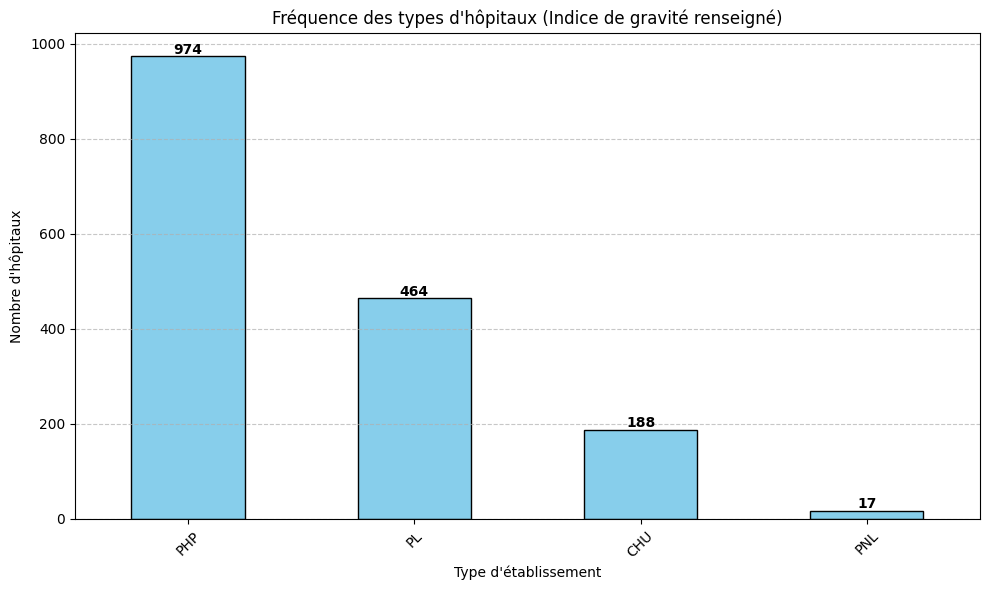

In [22]:
plt.figure(figsize=(10, 6))
frequences.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Fréquence des types d'hôpitaux (Indice de gravité renseigné)")
plt.xlabel("Type d'établissement")
plt.ylabel("Nombre d'hôpitaux")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(frequences):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()

In [23]:
prop_chu_gravite = data[(data['A9'].notna()) & (data['CHU'] == 1)].shape[0] / data[data["CHU"]==1].shape[0]
prop_pl_gravite = data[(data['A9'].notna()) & (data['PL'] == 1)].shape[0] / data[data["PL"]==1].shape[0]
prop_pnl_gravite = data[(data['A9'].notna()) & (data['PNL'] == 1)].shape[0] / data[data["PNL"]==1].shape[0]
prop_php_gravite =  data[(data['A9'].notna()) & (data['PHP'] == 1)].shape[0] / data[data["PHP"]==1].shape[0]

In [24]:
plot_data = pd.DataFrame(
    {'Proportion': [prop_chu_gravite, prop_pl_gravite, prop_pnl_gravite, prop_php_gravite]},
    index=['CHU', 'PL', 'PNL','PHP']
)

<Figure size 1000x600 with 0 Axes>

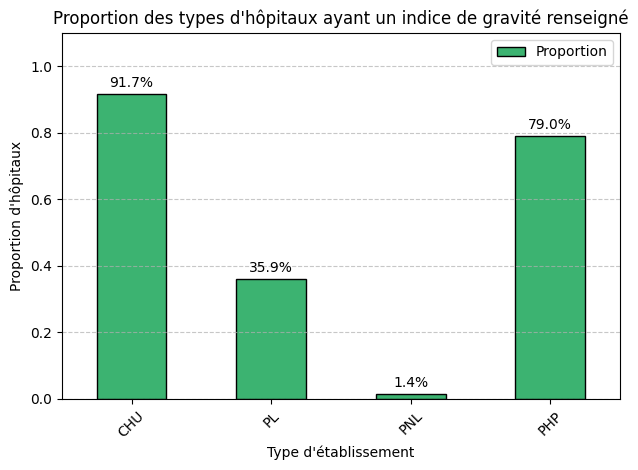

In [29]:
plt.figure(figsize=(10, 6))

ax = plot_data.plot(kind='bar', color='mediumseagreen', edgecolor='black')

for container in ax.containers:
    labels = [f'{val*100:.1f}%' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Proportion des types d'hôpitaux ayant un indice de gravité renseigné")
plt.xlabel("Type d'établissement")
plt.ylabel("Proportion d'hôpitaux")
plt.xticks(rotation=45)
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [28]:
missing = 'A9'
cov = ['EFFSAL_TOT', 'EFFLIB_TOT', 'EFF_DIR',
       'EFF_AUTADM', 'EFF_INFSANSSPE', 'SEAN_HEMO_CENTRE', 'SEAN_CHIMIO',
       'SEAN_RADIO', 'SEJ_HTP_TOT', 'VEN_HDJ_TOT', 'VEN_HDN_TOT', 'SEJHC_SSR',
       'ENT', 'EFF_AID', 'SEJHP_MCO', 'SEJHC_MCO', 'PASSU',
       'HEB_MED', 'HEB_CHIR', 'HEB_PERINAT', 'HEB_PSY', 'HEB_SSR', 'HEB_SLD',
       'MED', 'CHIRAMBU', 'PSY', 'RTH', 'CHIMIO', 'IRC', 'IVGAMP', 'CPP',
       'HAD', 'SSR', 'URG', 'SMURSAMU', 'EFF_MED', 'EFF_ADMIN',
       'EFF_IDE', 'SEANCES', 'SEJ_PSY', 'SEJ_SSR', 'ENT_SLD', 'lURG',
       'lMCO_AMB', 'lMCO_COMP', 'lPSY', 'lSEANCES', 'lSSR', 'lSLD', 'lMED',
       'lIDE', 'lAID', 'lADMIN']

# Sous-ensemble cible et covariables
cols_pour_knn = [missing] + cov
df_subset = data[cols_pour_knn]

# Normalisation
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_subset)

# KNN
imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = imputer.fit_transform(df_scaled)

# Dénormalisation et remplacement
df_temp = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=cols_pour_knn)
data['A9_imp'] = df_temp[missing].values

Exportation des valeurs imputées :

In [29]:
data[['FI','A9_imp']].to_csv("A9_imputed.csv", index=False)

### Indice de recherche et d'enseignement (A10)

In [30]:
data['A10'].isna().sum()/data.shape[0]

np.float64(0.8821464393179539)

88% des observations ont l'indice d'enseignement et de recherche renseigné. 

<Figure size 1000x600 with 0 Axes>

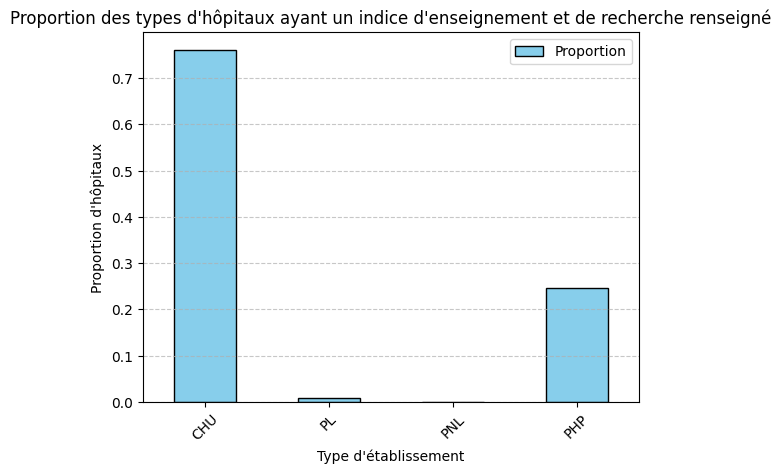

In [31]:
prop_chu_ens = data[(data['A10'].notna()) & (data['CHU'] == 1)].shape[0] / data[data["CHU"]==1].shape[0]
prop_pl_ens = data[(data['A10'].notna()) & (data['PL'] == 1)].shape[0] / data[data["PL"]==1].shape[0]
prop_pnl_ens = data[(data['A10'].notna()) & (data['PNL'] == 1)].shape[0] / data[data["PNL"]==1].shape[0]
prop_php_ens =  data[(data['A10'].notna()) & (data['PHP'] == 1)].shape[0] / data[data["PHP"]==1].shape[0]

plot_data = pd.DataFrame(
    {'Proportion': [prop_chu_ens, prop_pl_ens, prop_pnl_ens, prop_php_ens]},
    index=['CHU', 'PL', 'PNL','PHP']
)

plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Proportion des types d'hôpitaux ayant un indice d'enseignement et de recherche renseigné")
plt.xlabel("Type d'établissement")
plt.ylabel("Proportion d'hôpitaux")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Durée moyenne de séjours

In [32]:
data["duree_moy_mco"] = (data["SEJHC_MCO"]/data["JOU_MCO"]).fillna(0)

## Demande conditionnelle de facteurs avec contrôles

### Demande conditionnelle de facteurs avec contrôles et sans l'indicateur de gravité

In [33]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [34]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     3219.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:28:29   Log-Likelihood:                -6507.9
No. Observations:                3987   AIC:                         1.312e+04
Df Residuals:                    3937   BIC:                         1.343e+04
Df Model:                          49                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

In [35]:
dict

{('lMED', 'PL'): np.float64(111.64076788352682),
 ('lMED', 'PNL'): np.float64(12.313994950494234),
 ('lMED', 'CHU'): np.float64(-26.5928393624442),
 ('lIDE', 'PL'): np.float64(-48.362776717792364),
 ('lIDE', 'PNL'): np.float64(-63.56320416826136),
 ('lIDE', 'CHU'): np.float64(-19.844013621637945),
 ('lAID', 'PL'): np.float64(-68.832612295452),
 ('lAID', 'PNL'): np.float64(-76.12752634912478),
 ('lAID', 'CHU'): np.float64(-39.589839321888675),
 ('lADMIN', 'PL'): np.float64(55.024958574281754),
 ('lADMIN', 'PNL'): np.float64(36.45124102967845),
 ('lADMIN', 'CHU'): np.float64(-24.61132150350922)}

In [40]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     1373.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:29:56   Log-Likelihood:                -5442.2
No. Observations:                3987   AIC:                         1.098e+04
Df Residuals:                    3937   BIC:                         1.130e+04
Df Model:                          49                                         
Covariance Type:                  HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.2457      0.069     32.519      0.000       2.110       2.381
lURG              0.2910      0.095      3.065      0.002       0.105       0.477
lMCO_AMB          0.0368      0.019      1.959      0.050   -1.76e-05       0.074
lMCO_COMP         0.1331      0.024      5.543      0.000       0.086       0.180
lSSR              0.2102      0.034      6.129      0.000       0.143       0.277
lPSY              0.1107      0.015      7.391      0.000       0.081       0.140
lSEANCES          0.1312      0.022      5.896      0.000       0.088       0.175
lSLD              0.0388      0.043      0.901      0.368      -0.046       0.123
PNL              -1.0096      0.091    -11.131      0.000      -1.187      -0.832
PL               -0.6609      0.088     -7.541      0.000      -0.833      -0.489
CHU              -0.2212      0.217     -1.019      0.308      -0.647       0.204
HEB_MED          -0.3298      0.121     -2.727      0.006      -0.567      -0.093
HEB_CHIR          0.0077      0.153      0.050      0.960      -0.292       0.307
HEB_PERINAT       0.1379      0.107      1.285      0.199      -0.072       0.348
HEB_PSY           1.1462      0.096     11.998      0.000       0.959       1.333
HEB_SSR          -1.0121      0.188     -5.384      0.000      -1.381      -0.644
HEB_SLD           0.1061      0.142      0.749      0.454      -0.171       0.384
MED               0.2074      0.079      2.639      0.008       0.053       0.361
CHIRAMBU          0.1810      0.158      1.142      0.253      -0.130       0.492
PSY               0.2117      0.095      2.232      0.026       0.026       0.398
RTH              -0.7846      0.097     -8.064      0.000      -0.975      -0.594
CHIMIO            0.5670      0.065      8.781      0.000       0.440       0.694
IRC               0.0207      0.057      0.364      0.716      -0.091       0.132
IVGAMP           -0.0318      0.110     -0.289      0.773      -0.248       0.184
CPP               0.0931      0.100      0.927      0.354      -0.104       0.290
HAD               0.7358      0.068     10.782      0.000       0.602       0.870
SSR               0.2090      0.039      5.373      0.000       0.133       0.285
URG              -2.2213      0.895     -2.482      0.013      -3.976      -0.467
SMURSAMU         -0.8501      0.110     -7.718      0.000      -1.066      -0.634
lURG_PNL         -0.0227      0.027     -0.830      0.407      -0.076       0.031
lMCO_AMB_PNL      0.0345      0.029      1.186      0.236      -0.023       0.092
lMCO_COMP_PNL     0.0541      0.024      2.278      0.023       0.008       0.101
lSSR_PNL          0.1659      0.015     11.032      0.000       0.136       0.195
lPSY_PNL          0.0870      0.035      2.476      0.013       0.018       0.156
lSEANCES_PNL     -0.0331      0.031     -1.051   

### Demande conditionnelle de facteurs avec contrôles et l'indicateur de gravité

In [ ]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU","A9"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [28]:
for cont in controls:
    print(f"{data[cont].isna().sum()} | {cont}")

0 | PNL
0 | PL
0 | CHU
1 | HEB_MED
1 | HEB_CHIR
1 | HEB_PERINAT
1 | HEB_PSY
1 | HEB_SSR
1 | HEB_SLD
1 | MED
1 | CHIRAMBU
1 | PSY
1 | RTH
1 | CHIMIO
1 | IRC
1 | IVGAMP
1 | CPP
1 | HAD
1 | SSR
1 | URG
1 | SMURSAMU
2345 | A9


In [62]:
hd['A9'].isna().sum()

np.int64(221)

In [45]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     374.6
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:41:22   Log-Likelihood:                -2947.9
No. Observations:                1643   AIC:                             5990.
Df Residuals:                    1596   BIC:                             6244.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

/opt/python/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '
/opt/python/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                   lIDE   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     142.5
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:41:22   Log-Likelihood:                -1836.3
No. Observations:                1643   AIC:                             3767.
Df Residuals:                    1596   BIC:                             4021.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.1307      0.074     28.933

/opt/python/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '



Demande conditionnelle pour : lADMIN
                            OLS Regression Results                            
Dep. Variable:                 lADMIN   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     163.6
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:41:23   Log-Likelihood:                -2697.1
No. Observations:                1643   AIC:                             5488.
Df Residuals:                    1596   BIC:                             5742.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const   

/opt/python/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '


In [64]:
dict

{('lMED', 'PL'): np.float64(-14.795227467882544),
 ('lMED', 'PNL'): np.float64(-95.73813913404445),
 ('lMED', 'CHU'): np.float64(-16.714105777413867),
 ('lIDE', 'PL'): np.float64(-50.04555551296559),
 ('lIDE', 'PNL'): np.float64(-99.62488803598704),
 ('lIDE', 'CHU'): np.float64(-6.691412454119883),
 ('lAID', 'PL'): np.float64(-73.75408088238011),
 ('lAID', 'PNL'): np.float64(-99.46635237563349),
 ('lAID', 'CHU'): np.float64(-39.68286028779971),
 ('lADMIN', 'PL'): np.float64(112.9915898209767),
 ('lADMIN', 'PNL'): np.float64(-90.81704211290058),
 ('lADMIN', 'CHU'): np.float64(0.6438168725986015)}

In [47]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     142.5
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:41:49   Log-Likelihood:                -1836.3
No. Observations:                1643   AIC:                             3767.
Df Residuals:                    1596   BIC:                             4021.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.1307      0.074     28.933      0.000       1.986       2.275
lURG              0.2612      0.085      3.088      0.002       0.095       0.427
lMCO_AMB          0.0910      0.019      4.813      0.000       0.054       0.128
lMCO_COMP         0.1366      0.023      5.947      0.000       0.092       0.182
lSSR              0.0689      0.026      2.610      0.009       0.017       0.121
lPSY              0.0882      0.018      4.781      0.000       0.052       0.124
lSEANCES          0.0175      0.017      1.013      0.311      -0.016       0.051
lSLD              0.1557      0.048      3.234      0.001       0.061       0.250
PNL              -5.5857      0.825     -6.772      0.000      -7.202      -3.969
PL               -0.6941      0.208     -3.334      0.001      -1.102      -0.286
CHU              -0.0693      0.244     -0.284      0.776      -0.547       0.409
HEB_MED          -0.0566      0.103     -0.552      0.581      -0.257       0.144
HEB_CHIR         -0.0061      0.152     -0.040      0.968      -0.303       0.291
HEB_PERINAT       0.0663      0.075      0.881      0.378      -0.081       0.214
HEB_PSY           0.6782      0.193      3.520      0.000       0.301       1.056
HEB_SSR          -0.2019      0.145     -1.390      0.165      -0.487       0.083
HEB_SLD          -0.2297      0.160     -1.436      0.151      -0.543       0.084
MED              -0.0126      0.069     -0.183      0.855      -0.148       0.123
CHIRAMBU         -0.1820      0.154     -1.178      0.239      -0.485       0.121
PSY               0.1844      0.189      0.973      0.331      -0.187       0.556
RTH               0.2559      0.106      2.425      0.015       0.049       0.463
CHIMIO            0.3329      0.054      6.188      0.000       0.227       0.438
IRC               0.4085      0.063      6.437      0.000       0.284       0.533
IVGAMP           -0.0114      0.072     -0.159      0.873      -0.152       0.129
CPP              -0.0243      0.085     -0.286      0.775      -0.191       0.142
HAD               0.2136      0.066      3.258      0.001       0.085       0.342
SSR               0.2463      0.052      4.730      0.000       0.144       0.348
URG              -1.6243      0.796     -2.041      0.041      -3.184      -0.064
SMURSAMU         -0.7621      0.104     -7.334      0.000      -0.966      -0.558
A9               -0.0047      0.002     -2.621      0.009      -0.008      -0.001
lURG_PNL         -0.0768      0.029     -2.626      0.009      -0.134      -0.019
lMCO_AMB_PNL      0.0429      0.041      1.037      0.300      -0.038       0.124
lMCO_COMP_PNL     0.6343      0.106      6.003      0.000       0.427       0.841
lSSR_PNL       8.548e-15   1.34e-15      6.382      0.000    5.92e-15    1.12e-14
lPSY_PNL       5.306e-15   7.85e-16      6.757   

In [32]:
#OK : ajouter indic  HEB_MED, HEB_CHIR,HEB_PERINAT,HEB_PSY,HEB_SSR du fichier filtre (ils sont déjà en indic)

#OK: voir comment traiter USLD car beaucoup de données manquantes : si on l'inclut, ajouter indic ULSD HEB_SLD 
# -> ajouté USLD et indic malgré le manque de données

#OK: rajouter log output x statut juridique 

#OK: rajouter distiction CHU/petit hôpital public, mettre petits hopitaux publics en réf -> comment est ce qu'on fait vu 
#qu'on est au niveau du finess géographique : est ce que les unités appartenant à un CHU sont considérées comme CHU ? je dirais oui

#gros problème : avec le manque de sur l'indice de sévérité, on ne garde que environ 800 observations / 3998...
#est ce qu'on remplace par 0 quand c'est pas renseigné ? est ce qu'on approxime par la moyenne dans le département ? 
#essayer d'imputer par des établissements ressemblants => KNN ?(fait mais à voir si c'est vraiment pertinent)

#faire du log(1+x), quand indicatrice du service = 0, mettre 0 en output dans le service

#ajouter durée de séjour

#est ce qu'on distingue activité psychiatrique à temps complet et à temps partiel ? pour le moment agrégés dans PSY, 
#est ce que le temps partiel correspond à l'ambulatoire ? dans ce cas autant distinguer comme pour MCO ?

### Demande conditionnelle de facteurs avec contrôles et indice de gravité imputé

In [39]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU","A9_imp"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [40]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     3158.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:38:49   Log-Likelihood:                -6504.1
No. Observations:                3987   AIC:                         1.311e+04
Df Residuals:                    3936   BIC:                         1.343e+04
Df Model:                          50                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

In [67]:
dict

{('lMED', 'PL'): np.float64(111.91778843800653),
 ('lMED', 'PNL'): np.float64(13.03090393244426),
 ('lMED', 'CHU'): np.float64(-23.79418968679615),
 ('lIDE', 'PL'): np.float64(-48.461857656041),
 ('lIDE', 'PNL'): np.float64(-63.90202994361731),
 ('lIDE', 'CHU'): np.float64(-24.128871760719417),
 ('lAID', 'PL'): np.float64(-68.83745393328417),
 ('lAID', 'PNL'): np.float64(-76.1455597703118),
 ('lAID', 'CHU'): np.float64(-39.85769593434746),
 ('lADMIN', 'PL'): np.float64(55.46299519223488),
 ('lADMIN', 'PNL'): np.float64(38.33695738507708),
 ('lADMIN', 'CHU'): np.float64(-18.274415636385534)}

In [43]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     1113.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:39:25   Log-Likelihood:                -6291.9
No. Observations:                3987   AIC:                         1.269e+04
Df Residuals:                    3936   BIC:                         1.301e+04
Df Model:                          50                                         
Covariance Type:                  HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4456      0.093      4.778      0.000       0.263       0.628
lURG              0.5060      0.145      3.500      0.000       0.223       0.789
lMCO_AMB          0.0468      0.030      1.537      0.124      -0.013       0.107
lMCO_COMP         0.1563      0.034      4.662      0.000       0.091       0.222
lSSR              0.1723      0.044      3.950      0.000       0.087       0.258
lPSY              0.1350      0.021      6.503      0.000       0.094       0.176
lSEANCES          0.0797      0.022      3.587      0.000       0.036       0.123
lSLD             -0.0785      0.072     -1.096      0.273      -0.219       0.062
PNL               0.3245      0.107      3.041      0.002       0.115       0.534
PL                0.4412      0.106      4.149      0.000       0.233       0.650
CHU              -0.2018      0.212     -0.950      0.342      -0.618       0.215
HEB_MED          -0.3605      0.151     -2.393      0.017      -0.656      -0.065
HEB_CHIR          0.0936      0.244      0.383      0.702      -0.385       0.572
HEB_PERINAT       0.4717      0.178      2.646      0.008       0.122       0.821
HEB_PSY           0.6059      0.136      4.453      0.000       0.339       0.873
HEB_SSR          -0.8284      0.238     -3.475      0.001      -1.296      -0.361
HEB_SLD           0.2529      0.236      1.072      0.284      -0.210       0.715
MED               0.0628      0.076      0.822      0.411      -0.087       0.212
CHIRAMBU          0.3561      0.254      1.400      0.161      -0.142       0.855
PSY               0.4709      0.126      3.748      0.000       0.225       0.717
RTH               0.1937      0.129      1.501      0.133      -0.059       0.447
CHIMIO            0.4822      0.093      5.176      0.000       0.300       0.665
IRC              -0.5370      0.069     -7.799      0.000      -0.672      -0.402
IVGAMP           -0.2724      0.177     -1.540      0.123      -0.619       0.074
CPP              -0.2563      0.156     -1.645      0.100      -0.562       0.049
HAD               0.3892      0.091      4.290      0.000       0.211       0.567
SSR               0.2359      0.063      3.772      0.000       0.113       0.358
URG              -4.2372      1.361     -3.113      0.002      -6.905      -1.569
SMURSAMU         -0.2402      0.131     -1.830      0.067      -0.497       0.017
A9_imp            0.0151      0.003      5.658      0.000       0.010       0.020
lURG_PNL         -0.0302      0.035     -0.863      0.388      -0.099       0.038
lMCO_AMB_PNL      0.0477      0.038      1.261      0.207      -0.026       0.122
lMCO_COMP_PNL    -0.0132      0.027     -0.483      0.629      -0.067       0.040
lSSR_PNL          0.1643      0.020      8.231      0.000       0.125       0.203
lPSY_PNL          0.0290      0.032      0.896   

### Demande conditionnelle de facteurs avec contrôles et nombre de jours (sans indice de gravité)

In [32]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU","duree_moy_mco"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [33]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     3159.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:35:16   Log-Likelihood:                -6507.1
No. Observations:                3987   AIC:                         1.312e+04
Df Residuals:                    3936   BIC:                         1.344e+04
Df Model:                          50                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

In [34]:
dict

{('lMED', 'PL'): np.float64(111.59839094380008),
 ('lMED', 'PNL'): np.float64(12.06944608090723),
 ('lMED', 'CHU'): np.float64(-26.485027626217196),
 ('lIDE', 'PL'): np.float64(-48.385786474254964),
 ('lIDE', 'PNL'): np.float64(-63.73954963978132),
 ('lIDE', 'CHU'): np.float64(-19.58175695947807),
 ('lAID', 'PL'): np.float64(-68.84845885774008),
 ('lAID', 'PNL'): np.float64(-76.25931325751877),
 ('lAID', 'CHU'): np.float64(-39.364259723241965),
 ('lADMIN', 'PL'): np.float64(54.97912834551244),
 ('lADMIN', 'PNL'): np.float64(36.01278637594121),
 ('lADMIN', 'CHU'): np.float64(-24.44778055514021)}

In [38]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     1104.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:38:06   Log-Likelihood:                -6309.4
No. Observations:                3987   AIC:                         1.272e+04
Df Residuals:                    3936   BIC:                         1.304e+04
Df Model:                          50                                         
Covariance Type:                  HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6984      0.085      8.264      0.000       0.533       0.864
lURG              0.5102      0.141      3.618      0.000       0.234       0.787
lMCO_AMB          0.0265      0.030      0.869      0.385      -0.033       0.086
lMCO_COMP         0.1968      0.035      5.684      0.000       0.129       0.265
lSSR              0.1643      0.044      3.715      0.000       0.078       0.251
lPSY              0.1298      0.020      6.389      0.000       0.090       0.170
lSEANCES          0.0830      0.022      3.798      0.000       0.040       0.126
lSLD             -0.0687      0.072     -0.954      0.340      -0.210       0.072
PNL               0.3076      0.107      2.870      0.004       0.098       0.518
PL                0.4381      0.107      4.109      0.000       0.229       0.647
CHU              -0.2803      0.214     -1.313      0.189      -0.699       0.138
HEB_MED          -0.2879      0.156     -1.846      0.065      -0.594       0.018
HEB_CHIR          0.0620      0.246      0.252      0.801      -0.421       0.545
HEB_PERINAT       0.4292      0.177      2.424      0.015       0.082       0.776
HEB_PSY           0.6149      0.136      4.525      0.000       0.349       0.881
HEB_SSR          -0.7011      0.241     -2.907      0.004      -1.174      -0.228
HEB_SLD           0.2156      0.237      0.909      0.364      -0.249       0.681
MED              -0.0031      0.076     -0.041      0.967      -0.151       0.145
CHIRAMBU          0.3316      0.257      1.289      0.197      -0.173       0.836
PSY               0.4352      0.126      3.464      0.001       0.189       0.681
RTH               0.1884      0.129      1.458      0.145      -0.065       0.442
CHIMIO            0.4675      0.094      4.988      0.000       0.284       0.651
IRC              -0.5852      0.068     -8.603      0.000      -0.718      -0.452
IVGAMP           -0.2649      0.177     -1.499      0.134      -0.611       0.082
CPP              -0.2989      0.156     -1.917      0.055      -0.605       0.007
HAD               0.4091      0.090      4.543      0.000       0.233       0.586
SSR               0.1564      0.060      2.595      0.009       0.038       0.274
URG              -4.3664      1.329     -3.284      0.001      -6.972      -1.761
SMURSAMU         -0.2536      0.132     -1.919      0.055      -0.513       0.005
duree_moy_mco    -0.2935      0.182     -1.611      0.107      -0.650       0.064
lURG_PNL         -0.0210      0.035     -0.604      0.546      -0.089       0.047
lMCO_AMB_PNL      0.0358      0.037      0.962      0.336      -0.037       0.109
lMCO_COMP_PNL    -0.0208      0.027     -0.775      0.438      -0.073       0.032
lSSR_PNL          0.1710      0.020      8.524      0.000       0.132       0.210
lPSY_PNL          0.0327      0.032      1.027   